## Working with text Data 
in this notebook i am familiarizing myself with the tokenization part of building LLMs 

In [1]:
import os 
import urllib.request

In [2]:
if not os.path.exists("the-verdict.txt"):
    url = ("https://raw.githubusercontent.com/rasbt/"
           "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
           "the-verdict.txt")
    file_path  = 'the-verdict.txt'
    urllib.request.urlretrieve(url , file_path)

In [3]:
with open('the-verdict.txt' , 'r' , encoding='utf-8') as f:
    raw_text = f.read()

In [4]:
len(raw_text)

20479

In [7]:
import re

text = "Hello, world. This is a test."
result = re.split(r'(\s)' , text)
print(result)

['Hello,', ' ', 'world.', ' ', 'This', ' ', 'is', ' ', 'a', ' ', 'test.']


In [9]:
result = [item for item in result if item.strip()]
print(result)

['Hello,', 'world.', 'This', 'is', 'a', 'test.']


In [ ]:
text = "Hello, world. Is this-- a test?"

result = re.split(r'([,.:;?_!"()\']|--|\s)' , raw_text)
result = [item.strip() for item in result if item.strip()]
preprocessed = result
print(len(preprocessed))

4690


In [11]:
preprocessed[:10]

['I',
 'HAD',
 'always',
 'thought',
 'Jack',
 'Gisburn',
 'rather',
 'a',
 'cheap',
 'genius']

In [ ]:
# converting tokens to token ids
all_words = sorted(set(preprocessed)) # remove the duplicates
len(all_words)

1130

In [ ]:
vocab = {token:integer for integer , token in enumerate(all_words)}
vocab # this is a vocabulary consisting of our words like a dictionary

{'!': 0,
 '"': 1,
 "'": 2,
 '(': 3,
 ')': 4,
 ',': 5,
 '--': 6,
 '.': 7,
 ':': 8,
 ';': 9,
 '?': 10,
 'A': 11,
 'Ah': 12,
 'Among': 13,
 'And': 14,
 'Are': 15,
 'Arrt': 16,
 'As': 17,
 'At': 18,
 'Be': 19,
 'Begin': 20,
 'Burlington': 21,
 'But': 22,
 'By': 23,
 'Carlo': 24,
 'Chicago': 25,
 'Claude': 26,
 'Come': 27,
 'Croft': 28,
 'Destroyed': 29,
 'Devonshire': 30,
 'Don': 31,
 'Dubarry': 32,
 'Emperors': 33,
 'Florence': 34,
 'For': 35,
 'Gallery': 36,
 'Gideon': 37,
 'Gisburn': 38,
 'Gisburns': 39,
 'Grafton': 40,
 'Greek': 41,
 'Grindle': 42,
 'Grindles': 43,
 'HAD': 44,
 'Had': 45,
 'Hang': 46,
 'Has': 47,
 'He': 48,
 'Her': 49,
 'Hermia': 50,
 'His': 51,
 'How': 52,
 'I': 53,
 'If': 54,
 'In': 55,
 'It': 56,
 'Jack': 57,
 'Jove': 58,
 'Just': 59,
 'Lord': 60,
 'Made': 61,
 'Miss': 62,
 'Money': 63,
 'Monte': 64,
 'Moon-dancers': 65,
 'Mr': 66,
 'Mrs': 67,
 'My': 68,
 'Never': 69,
 'No': 70,
 'Now': 71,
 'Nutley': 72,
 'Of': 73,
 'Oh': 74,
 'On': 75,
 'Once': 76,
 'Only': 77,
 '

In [29]:
# building a simple tokenizer 
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab                # Store the vocabulary as a class attribute for access in the encode and decode methods                   
        self.int_to_str = {i:s for s,i in vocab.items()}  # Create an inverse vocabulary that maps token IDs back to the original text tokens  

    def encode(self, text):                                       # text to token ids
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
    def decode(self, ids):                                  # token ids to text      
        text = " ".join([self.int_to_str[i] for i in ids]) 
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)           # replace spaces before specified punctuation
        return text

In [31]:
tokenizer = SimpleTokenizerV1(vocab)
text = "this is me , Gisburn"
ids = tokenizer.encode(text)
print(ids)

[999, 584, 663, 5, 38]


In [34]:
print(tokenizer.decode(ids)) # yyee our text is decoded
# also wait you can't encode any text because our v1 tokenizer is based on vocabulary of the text file ,
# so something outside of that raw text file would result in error 

this is me, Gisburn


##### Adding special context tokens and Byte pair encoding

In [57]:
all_tokens = sorted(set(preprocessed))
all_tokens.extend(["<|endoftext|>" , "<|unk|>"])

vocab = {token:integer for integer , token in enumerate(all_tokens)}
print(len(vocab)) # earlier 1130 now 1132

1132


In [58]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [60]:
class SimpleTokenizerV2:
   def __init__(self, vocab):
       self.str_to_int = vocab
       self.int_to_str = { i:s for s,i in vocab.items()}
   
   def encode(self, text):
       preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
       preprocessed = [item.strip() for item in preprocessed if item.strip()]
       preprocessed = [item if item in self.str_to_int           # replace unknown words by unk tokens 
                       else "<|unk|>" for item in preprocessed]
       ids = [self.str_to_int[s] for s in preprocessed]
       return ids
       
   def decode(self, ids):
       text = " ".join([self.int_to_str[i] for i in ids])
       text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)           # replace spaces before specified punctuation
       return text

In [63]:
tokenizer = SimpleTokenizerV2(vocab)

text = "hello this is me , hahaha"
ids = tokenizer.encode(text)
ids

[1131, 999, 584, 663, 5, 1131]

In [65]:
tokenizer.decode(ids) # now we can see how the unknown words have been replaced by unk 

'<|unk|> this is me, <|unk|>'

In [66]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1, text2))
print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [67]:
print(tokenizer.decode(tokenizer.encode(text)))

<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


In [68]:
# BYTE PAIR ENCODING
#BPE is a subword tokenization algorithm used in NLP to convert text into tokens that are 
# smaller than words but larger than characters.

#example : unknownappleasfhkjkz can still be understood by tokenizer and break down as unknown , apple , as , f , h , k etc..

In [76]:
import tiktoken
tokenizer = tiktoken.get_encoding('gpt2')
ids = tokenizer.encode('Akwir ier')
print(ids)

[33901, 86, 343, 220, 959]


In [77]:
tokenizer.decode(ids)

'Akwir ier'

##### Data sampling with a sliding window

In [78]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [87]:
enc_sample = enc_text[50:] # 5145 - 50 = 5095
len(enc_sample)

5095

In [88]:
context_size = 4
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x : {x}")
print(f"y:      {y}")

x : [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [90]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(context, "---->", desired) # its like predicting the next word

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [91]:
import torch
torch.__version__

'2.10.0+cpu'

In [92]:
import torch
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
   def __init__(self, txt, tokenizer, max_length, stride):
       self.input_ids = []
       self.target_ids = []
       token_ids = tokenizer.encode(txt)                         # tokenize entire text
       for i in range(0, len(token_ids) - max_length, stride):   # use sliding window type approach
           input_chunk = token_ids[i:i + max_length]
           target_chunk = token_ids[i + 1: i + max_length + 1]
           self.input_ids.append(torch.tensor(input_chunk))
           self.target_ids.append(torch.tensor(target_chunk))
   def __len__(self):                                            # return total number of rows in dataset
       return len(self.input_ids)
   def __getitem__(self, idx):                                   # return a single row
       return self.input_ids[idx], self.target_ids[idx]

PyTorch DataLoader is a utility that efficiently loads data from a Dataset and provides it to the model in batches, with support for shuffling, parallel loading, and iteration during training and evaluation.

In [94]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
       stride=128, shuffle=True, drop_last=True, num_workers=0):
   tokenizer = tiktoken.get_encoding("gpt2")                   # initialise tokenizer
   dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)    # create dataset
   dataloader = DataLoader(
       dataset,
       batch_size=batch_size,
       shuffle=shuffle,
       drop_last=drop_last,                                      # drops the last batch if the last batch is shorter than 
                                                                # specified batch to prevent loss spikes during training
       num_workers=0                                             # number of cpu processes used for preprocessing
   )
   return dataloader

In [99]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
   raw_text = f.read()
dataloader = create_dataloader_v1(
   raw_text, batch_size=1, max_length=4, stride=4, shuffle=False)
data_iter = iter(dataloader)                                      # convert dataloader into a Python iterator to fetch 
first_batch = next(data_iter)                                     # the next entry via Python's built-in next() function
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [100]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[1807, 3619,  402,  271]]), tensor([[ 3619,   402,   271, 10899]])]


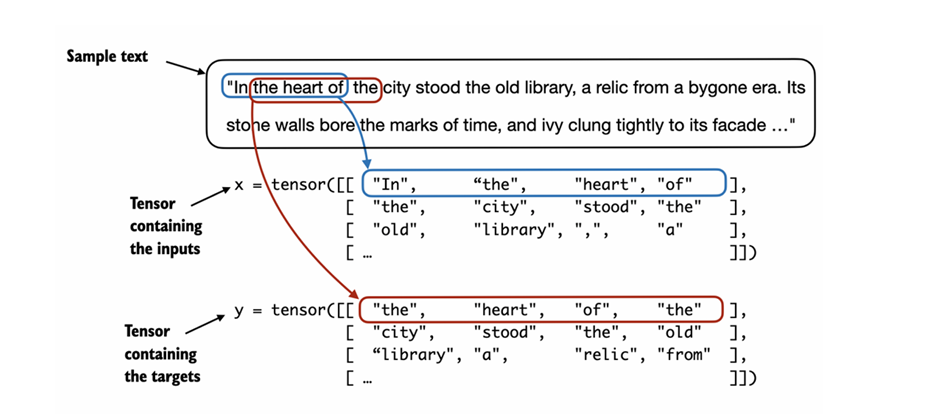

In [101]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[  416,   502,  2474,   198],
        [  565,   593,   338, 25304],
        [  550,   587,  6699,   262],
        [  517, 12949,  1295,  2627],
        [   13,   402,   271, 10899],
        [37733,  2346,   284,   884],
        [  547,  2982,    11,   290],
        [  262,  2589,   314,   373]])

Targets:
 tensor([[  502,  2474,   198,   198],
        [  593,   338, 25304,  4040],
        [  587,  6699,   262,  1540],
        [12949,  1295,  2627,   262],
        [  402,   271, 10899,   338],
        [ 2346,   284,   884, 14177],
        [ 2982,    11,   290,   287],
        [ 2589,   314,   373,  4808]])


##### Create token embeddings 

nn.Linear(128, 64)
Maps 128-dim features → 64-dim features

nn.Embedding is a lookup table that maps discrete indices → dense vectors.
Converts integers (IDs) into learned vector representations
ex. nn.Embedding(vocab_size=50_000, embedding_dim=768)


In [102]:
input_ids = torch.tensor([2,3,5,1])

In [107]:
vocab_size = 6
output_dim = 3 # or dimension of the embeddings
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size , output_dim)
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [109]:
## Encoding word positions

vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size , output_dim)

max_length = 4
dataloader = create_dataloader_v1(raw_text , batch_size=8 , max_length=max_length , stride=max_length , shuffle=False)
data_iter = iter(dataloader)

inputs , targets = next(data_iter)

In [110]:
print("Token ID's: \n", inputs)
print('\n Inputs shape : \n', inputs.shape)

Token ID's: 
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

 Inputs shape : 
 torch.Size([8, 4])


In [ ]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)
print()
print(token_embeddings)
# 8 batches , 4 rows , 256 columns

torch.Size([8, 4, 256])

tensor([[[ 0.3045, -2.2610, -0.4094,  ..., -1.6522, -0.2868,  1.2438],
         [-0.2460,  0.2528,  0.2237,  ..., -0.7093, -0.6564, -1.2014],
         [ 0.4986,  0.1621,  0.6822,  ...,  1.1171,  0.2367,  0.2138],
         [-0.5436,  0.6707,  2.0537,  ..., -0.6127,  0.5454, -0.9175]],

        [[-0.4044,  0.3227,  1.0297,  ...,  0.0570,  0.7727, -0.0346],
         [-0.2779,  0.7304,  2.0882,  ...,  1.0014,  0.1509, -0.5499],
         [-1.4237,  0.5973, -1.3234,  ..., -0.4272,  1.0466, -0.1104],
         [-1.5506,  0.1693,  1.4931,  ..., -0.3387, -1.0787, -1.2689]],

        [[ 1.4963,  0.5346,  0.8751,  ...,  2.5655, -0.7914,  1.6417],
         [-0.5089, -1.4528, -0.4107,  ...,  0.7509,  0.4721,  0.3420],
         [ 0.0118, -1.0189,  0.1589,  ...,  0.5212, -0.2544,  0.9034],
         [-0.6605,  0.8879, -0.3432,  ...,  0.0128,  0.4897, -0.2956]],

        ...,

        [[ 1.2109, -1.1724, -1.9072,  ...,  0.6573, -2.3168,  2.6120],
         [ 0.4538,  1.3213,  0.0

In [116]:
torch.arange(max_length)

tensor([0, 1, 2, 3])

In [121]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
print(pos_embedding_layer.weight)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print()
print(pos_embeddings.shape)
print()
print(pos_embeddings)

Parameter containing:
tensor([[ 0.5541,  0.2663, -1.7872,  ...,  1.6127, -0.4554,  0.8643],
        [-0.8853,  1.6266,  1.1460,  ..., -1.0436,  0.1946, -1.9637],
        [-1.0525, -0.2973, -0.2878,  ...,  1.7664, -2.4395,  1.1522],
        [-1.6935, -0.5116,  0.7679,  ..., -1.4666,  0.6895, -0.0929]],
       requires_grad=True)

torch.Size([4, 256])

tensor([[ 0.5541,  0.2663, -1.7872,  ...,  1.6127, -0.4554,  0.8643],
        [-0.8853,  1.6266,  1.1460,  ..., -1.0436,  0.1946, -1.9637],
        [-1.0525, -0.2973, -0.2878,  ...,  1.7664, -2.4395,  1.1522],
        [-1.6935, -0.5116,  0.7679,  ..., -1.4666,  0.6895, -0.0929]],
       grad_fn=<EmbeddingBackward0>)


In [ ]:
input_embeddings = token_embeddings + pos_embeddings # pytorch adds each of the 4x256 positional info to all the 8 batches
print(input_embeddings.shape)                       # each separately 

torch.Size([8, 4, 256])
